# Task 2 - Gestalt principles of grouping

Data: `stimuli_gestalt.csv` (six panels), `tips.csv`.

In [1]:
%matplotlib inline

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

GREY = "#bbbbbb"
GREY_DARK = "#777777"
ACCENT = "#ee6677"
BLUE = "#4477aa"
INK = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": GREY_DARK,
    "xtick.color": GREY_DARK,
    "ytick.color": GREY_DARK,
})


def declutter(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


def save(fig, name):
    fig.savefig(CHARTS / f"{name}.png", dpi=300, bbox_inches="tight")

from matplotlib.patches import Rectangle

In [2]:
gestalt = pd.read_csv(DATA / "stimuli_gestalt.csv")
gestalt.groupby("panel").agg(items=("x", "size"), groups=("group", "nunique"))

,items,groups
panel,,
closure,44,2
connection,48,24
continuity,48,2
enclosure,48,4
proximity,48,4
similarity,48,4


## 1. All six panels

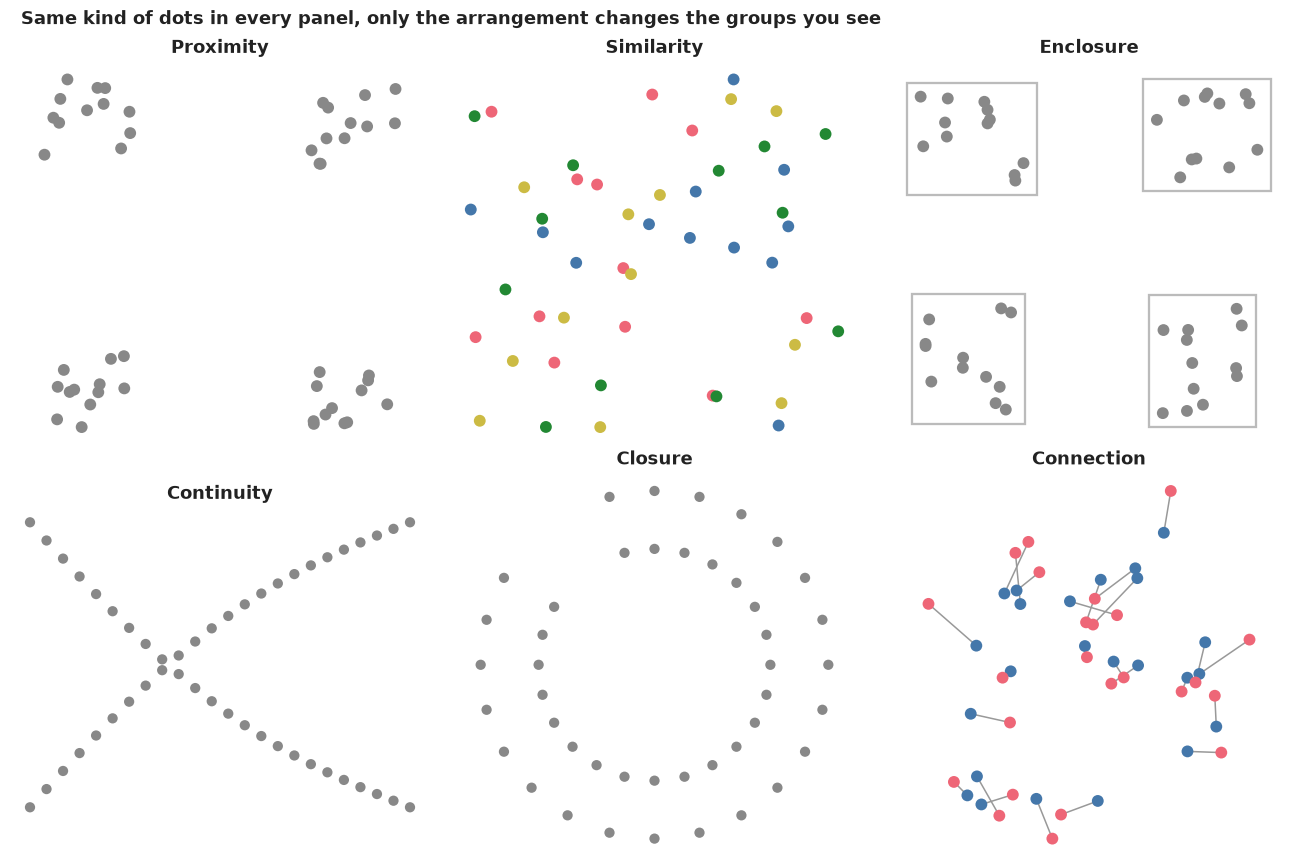

In [3]:
PANELS = ["proximity", "similarity", "enclosure", "continuity", "closure", "connection"]


def draw_panel(name, ax, lines=True):
    p = gestalt[gestalt["panel"] == name]
    colours = p["colour"].replace({"grey": "#888888"})

    if name == "enclosure":
        for _, g in p.groupby("group"):
            x0, x1 = g["x"].min() - 0.3, g["x"].max() + 0.3
            y0, y1 = g["y"].min() - 0.3, g["y"].max() + 0.3
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                   edgecolor=GREY, linewidth=1.5))

    if name == "connection" and lines:
        for _, pair in p.groupby("connector"):
            ax.plot(pair["x"], pair["y"], color="#999999", linewidth=1, zorder=1)

    ax.scatter(p["x"], p["y"], s=p["size"], color=colours, zorder=2, edgecolors="none")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, name in zip(axes.flat, PANELS):
    draw_panel(name, ax)
    ax.set_title(name.capitalize(), loc="center")
fig.suptitle("Same kind of dots in every panel, only the arrangement changes the groups you see",
             x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "task2_six_panels")
plt.show()

- **Proximity** - same grey dots, but four clumps with empty space between them. Space alone makes four groups.
- **Similarity** - one even cloud, no spatial gaps. The only thing that groups is hue, so you see four colour sets mixed together. I didn't move them apart, otherwise this would just be proximity again.
- **Enclosure** - the grey boxes are the only thing I added. Things inside the same boundary read as a unit.
- **Continuity** - two curves cross in the middle. The eye follows each smooth path through the crossing instead of seeing an X made of four short pieces.
- **Closure** - two incomplete loops with a gap. The brain fills the gap and sees two closed shapes. 44 items, the gap is meant to be there.
- **Connection** - lines join pairs of different colours that aren't always nearest neighbours. The line wins.

## 2. Asking a real person "how many groups do you see?"

Fill `perceived` with what the reader said for each panel (show them the figure above, one panel at a time if you can, covering the others).

In [4]:
READER = "Sami (self-test)"

perceived = {
    "proximity": None,
    "similarity": None,
    "enclosure": None,
    "continuity": None,
    "closure": None,
    "connection": None,
}

true_groups = gestalt.groupby("panel")["group"].nunique()
table = pd.DataFrame({
    "panel": PANELS,
    "principle": [p.capitalize() for p in PANELS],
    "true groups": [true_groups[p] for p in PANELS],
    "perceived groups": [perceived[p] for p in PANELS],
})
table["match"] = np.where(table["perceived groups"].isna(), "not asked yet",
                          np.where(table["perceived groups"] == table["true groups"], "yes", "no"))
table

,panel,principle,true groups,perceived groups,match
0,proximity,Proximity,4,None,not asked yet
1,similarity,Similarity,4,None,not asked yet
2,enclosure,Enclosure,4,None,not asked yet
3,continuity,Continuity,2,None,not asked yet
4,closure,Closure,2,None,not asked yet
5,connection,Connection,24,None,not asked yet


_(Notes on the reader's answers, e.g. anything they said out loud, which ones they hesitated on.)_

## 3. Making the principles fight

In the connection panel each pair is one blue + one red dot, and the partner is often not the closest dot. So similarity says "2 groups (blue / red)", proximity says "whatever clumps are nearby", and connection says "24 pairs". I showed it with and without the lines.

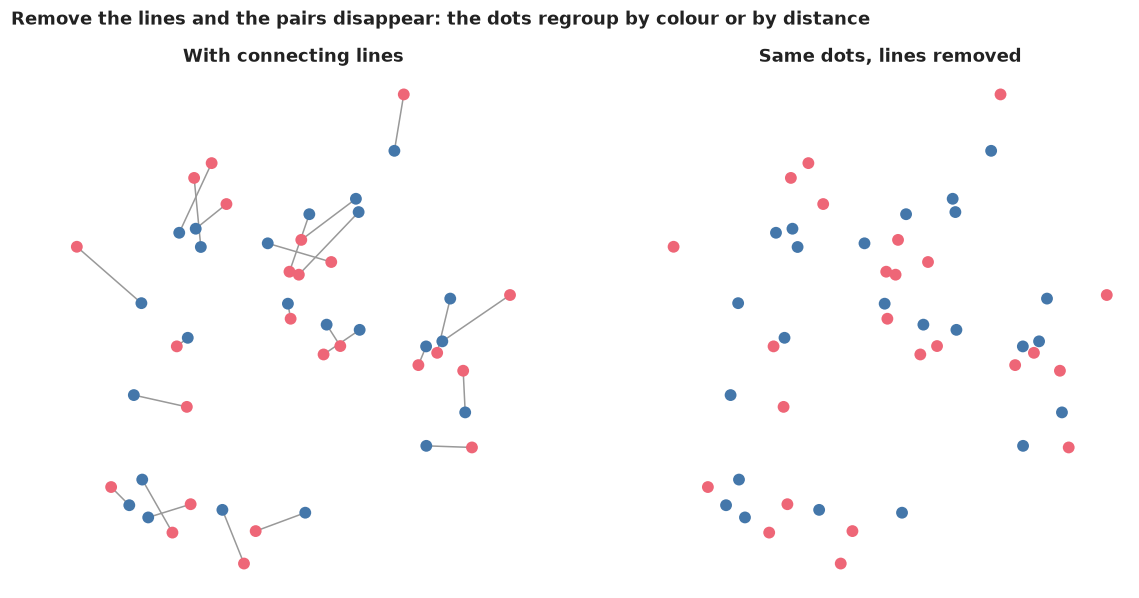

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
draw_panel("connection", axes[0], lines=True)
draw_panel("connection", axes[1], lines=False)
axes[0].set_title("With connecting lines", loc="center")
axes[1].set_title("Same dots, lines removed", loc="center")
fig.suptitle("Remove the lines and the pairs disappear: the dots regroup by colour or by distance",
             x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "task2_connection_fight")
plt.show()

**Chart analysis.**

With the lines drawn you see 24 connected pairs.  
Take the lines away and the same dots regroup by colour or by distance.  
Connection is strong, but it needs the lines. (My counts are not recorded yet.)

In [6]:
with_lines_answer = "what the reader said with the lines"
without_lines_answer = "what the reader said without the lines"
print("with lines:   ", with_lines_answer)
print("without lines:", without_lines_answer)

with lines:    what the reader said with the lines
without lines: what the reader said without the lines


**Which principle won?** _(fill in from the answers above)_

Theory says connection should beat both, since a line is a physical link and the visual system treats connected things as one object. Without the lines, I'd expect them to group by colour (2 groups) or by little clumps (proximity). If my reader did something else, say so here and why.

## 4. Proximity in a real chart (`tips.csv`)

Average tip as % of the bill, by day, split by the sex of the person paying. Version A puts the two bars for a day close together and leaves a bigger gap between days. Version B uses the same bars with every gap equal.

In [7]:
tips = pd.read_csv(DATA / "tips.csv")
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100

days = ["Thur", "Fri", "Sat", "Sun"]
summary = (tips.groupby(["day", "sex"])["tip_pct"].agg(["mean", "size"])
           .reindex(pd.MultiIndex.from_product([days, ["Female", "Male"]])))
summary

mean  size
Thur Female  15.752483    32
     Male    16.527649    30
Fri  Female  19.938840     9
     Male    14.338519    10
Sat  Female  15.647021    28
     Male    15.157684    59
Sun  Female  18.156877    18
     Male    16.234407    58

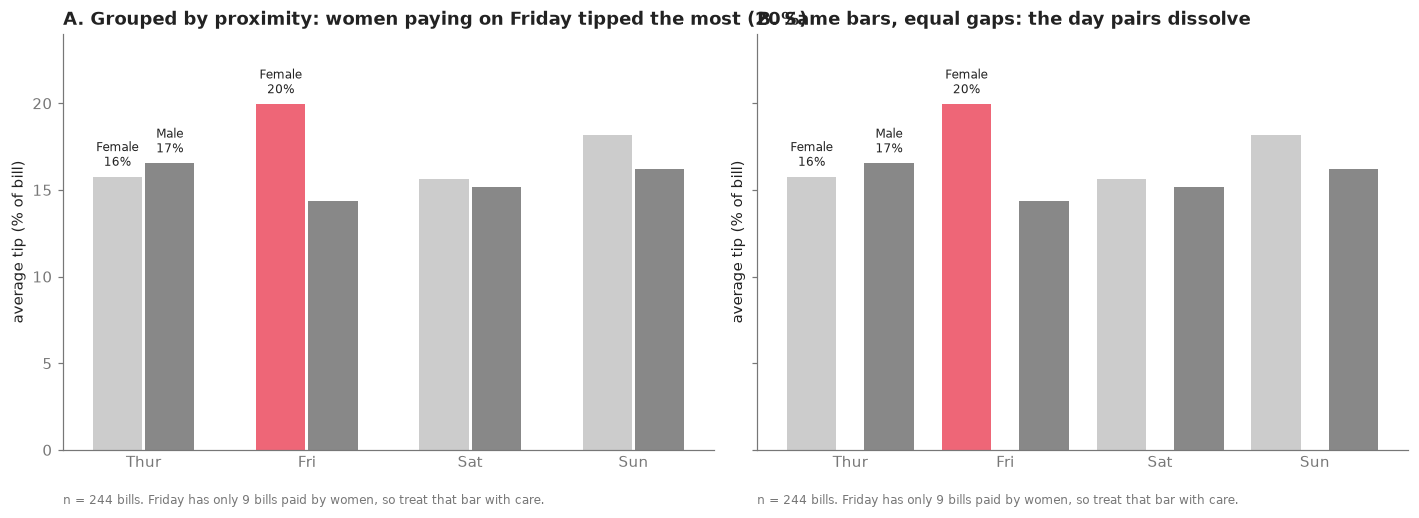

In [8]:
SHADE = {"Female": "#cccccc", "Male": "#888888"}


def tip_bars(ax, within_gap, between_gap, width=0.8):
    pos, x = [], 0.0
    for d in days:
        pos.append((d, "Female", x))
        pos.append((d, "Male", x + width + within_gap))
        x += 2 * width + within_gap + between_gap
    for d, sex, xpos in pos:
        val = summary.loc[(d, sex), "mean"]
        colour = ACCENT if (d == "Fri" and sex == "Female") else SHADE[sex]
        ax.bar(xpos, val, width=width, color=colour, align="edge")
        if d == "Thur" or (d == "Fri" and sex == "Female"):
            ax.text(xpos + width / 2, val + 0.4, f"{sex}\n{val:.0f}%", ha="center", va="bottom", fontsize=8)
    centres = [(pos[2 * i][2] + pos[2 * i + 1][2] + width) / 2 for i in range(len(days))]
    ax.set_xticks(centres)
    ax.set_xticklabels(days)
    ax.tick_params(axis="x", length=0)
    ax.set_ylim(0, 24)
    ax.set_ylabel("average tip (% of bill)")
    declutter(ax)


n_fri = int(summary.loc[("Fri", "Female"), "size"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
tip_bars(axes[0], within_gap=0.05, between_gap=1.0)
tip_bars(axes[1], within_gap=0.45, between_gap=0.45)
axes[0].set_title("A. Grouped by proximity: women paying on Friday tipped the most (20%)")
axes[1].set_title("B. Same bars, equal gaps: the day pairs dissolve")
for ax in axes:
    ax.text(0, -0.13, f"n = {len(tips)} bills. Friday has only {n_fri} bills paid by women, so treat that bar with care.",
            transform=ax.transAxes, fontsize=8, color=GREY_DARK)
fig.tight_layout()
save(fig, "task2_tips_proximity")
plt.show()

Same eight numbers in both. In A the small gap inside a day and the bigger gap between days make each pair one unit (**proximity**), so women vs men reads without effort.  
In B every gap is equal, so the bars read as a row of eight and the reader has to count across from the tick label to find Friday's pair.  
Attributes: bar height (length from a zero baseline) for the number, light/dark grey for sex, and one red pop-out for the Friday/women bar the title is about.

## 5. Where each principle already lives in charts

- **Proximity** - small multiples: panels that sit near each other read as one set, and a facet title sitting right above its panel is read as belonging to it.
- **Similarity** - a legend works because every mark with the same colour is read as the same series, everywhere on the chart.
- **Enclosure** - a shaded band behind a line chart (like a recession period) groups all the points inside it as "that period".
- **Closure** - a chart with only left and bottom spines still reads as a closed plotting area; the brain completes the missing box.
- **Continuity** - in a line chart, we follow one line through crossings with other lines because we track the smoothest path.
- **Connection** - the line in a line chart is itself connection: it turns 12 separate yearly points into one country's trend. Same with the lines in a slope chart or the rules in a table that join a row together.

## The question: legend vs direct labels

A legend uses **similarity**: the reader has to notice a colour on the chart, keep it in working memory, move their eyes to the legend, find the matching swatch, read the name, then go back to the data and find the spot again. Each series costs at least one chunk of working memory (colour → name), and with 4+ series the ~4 chunk limit is used up on lookup alone. That's all extraneous load.

A direct label uses **proximity**: the name sits next to the line or bar it describes, so the eye reads the mark and the name together, at the same place. Nothing has to be held in memory and there's no back-and-forth eye movement. The matching has already happened on the page, so more of the reader's limited memory goes to the actual comparison (germane load).